<a href="https://colab.research.google.com/github/Asigen93/Measurement-Report-Skripsi/blob/main/measurement_report_4G_LTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ============================================
# IMPORT LIBRARY
# ============================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (14,6)

In [9]:
# ============================================
# UPLOAD FILE
# ============================================
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Baca file excel
df = pd.read_excel(filename)

Saving Buat measurement Report.xlsx to Buat measurement Report (2).xlsx


In [10]:
# ============================================
# BERSIHKAN NAMA KOLOM
# ============================================
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\n', ' ', regex=True)
df.columns = df.columns.str.replace('  ', ' ', regex=False)

print("=== NAMA KOLOM TERBACA ===")
print(df.columns.tolist())

=== NAMA KOLOM TERBACA ===
['Hari 1', 'No.', 'Skenario (Lock)', 'Timing Advance (m/km)', 'Band (Mhz)', 'Band width (MHz)', 'RSRP (dBm)', 'RSRQ (dB)', 'SNR (dB)', 'Time Download File     (20 mb)', 'Time Upload File', 'Throughput DL (Mbps)', 'Throughput UL (Mbps)', 'Kategori']


In [11]:
# ============================================
# DEFINISIKAN KOLOM SESUAI FILE ANDA
# ============================================
col_rsrp = 'RSRP (dBm)'
col_rsrq = 'RSRQ (dB)'
col_snr = 'SNR (dB)'
col_dl = 'Throughput DL (Mbps)'
col_ul = 'Throughput UL (Mbps)'

In [12]:
# ============================================
# VALIDASI KOLOM
# ============================================
required_cols = [col_rsrp, col_rsrq, col_snr, col_dl, col_ul]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan: {missing_cols}")

In [13]:
# ============================================
# TAMPILKAN DATA AWAL
# ============================================
display(df.head())

,Hari 1,No.,Skenario (Lock),Timing Advance (m/km),Band (Mhz),Band width (MHz),RSRP (dBm),RSRQ (dB),SNR (dB),Time Download File (20 mb),Time Upload File,Throughput DL (Mbps),Throughput UL (Mbps),Kategori
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(20 mb),NaN,NaN,NaN
1,NaN,1.,EARFCN 500 PCI 261,± 312 m,B1 (2100),20,-91,-14,4.8,16 detik,32 detik,10,5,NaN
2,NaN,2.,EARFCN 1850 PCI 261,± 312 m,B3 (1800),20,-93,-13,20,19 detik,24 detik,8.4,6.7,NaN
3,NaN,3.,EARFCN 3500 PCI 261,± 312 m,B8 (900),10,-79,-11,8.2,58 detik,27 detik,2.8,5.9,NaN
4,NaN,4.,EARFCN 500 PCI 214,± 156 m,B1 (2100),20,-88,-10,30,14 detik,26 detik,11.4,6.2,NaN


In [15]:
# ============================================
# KOLOM NUMERIK YANG AKAN DIPLOTTING
# ============================================
numeric_cols = [
    col_rsrp,
    col_rsrq,
    col_snr,
    col_dl,
    col_ul
]

In [16]:
# ============================================
# KONVERSI KE NUMERIK (STRING JADI NaN)
# ============================================
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [17]:
# ============================================
# HAPUS BARIS YANG BUKAN DATA NUMERIK
# ============================================
df = df.dropna(subset=numeric_cols).reset_index(drop=True)

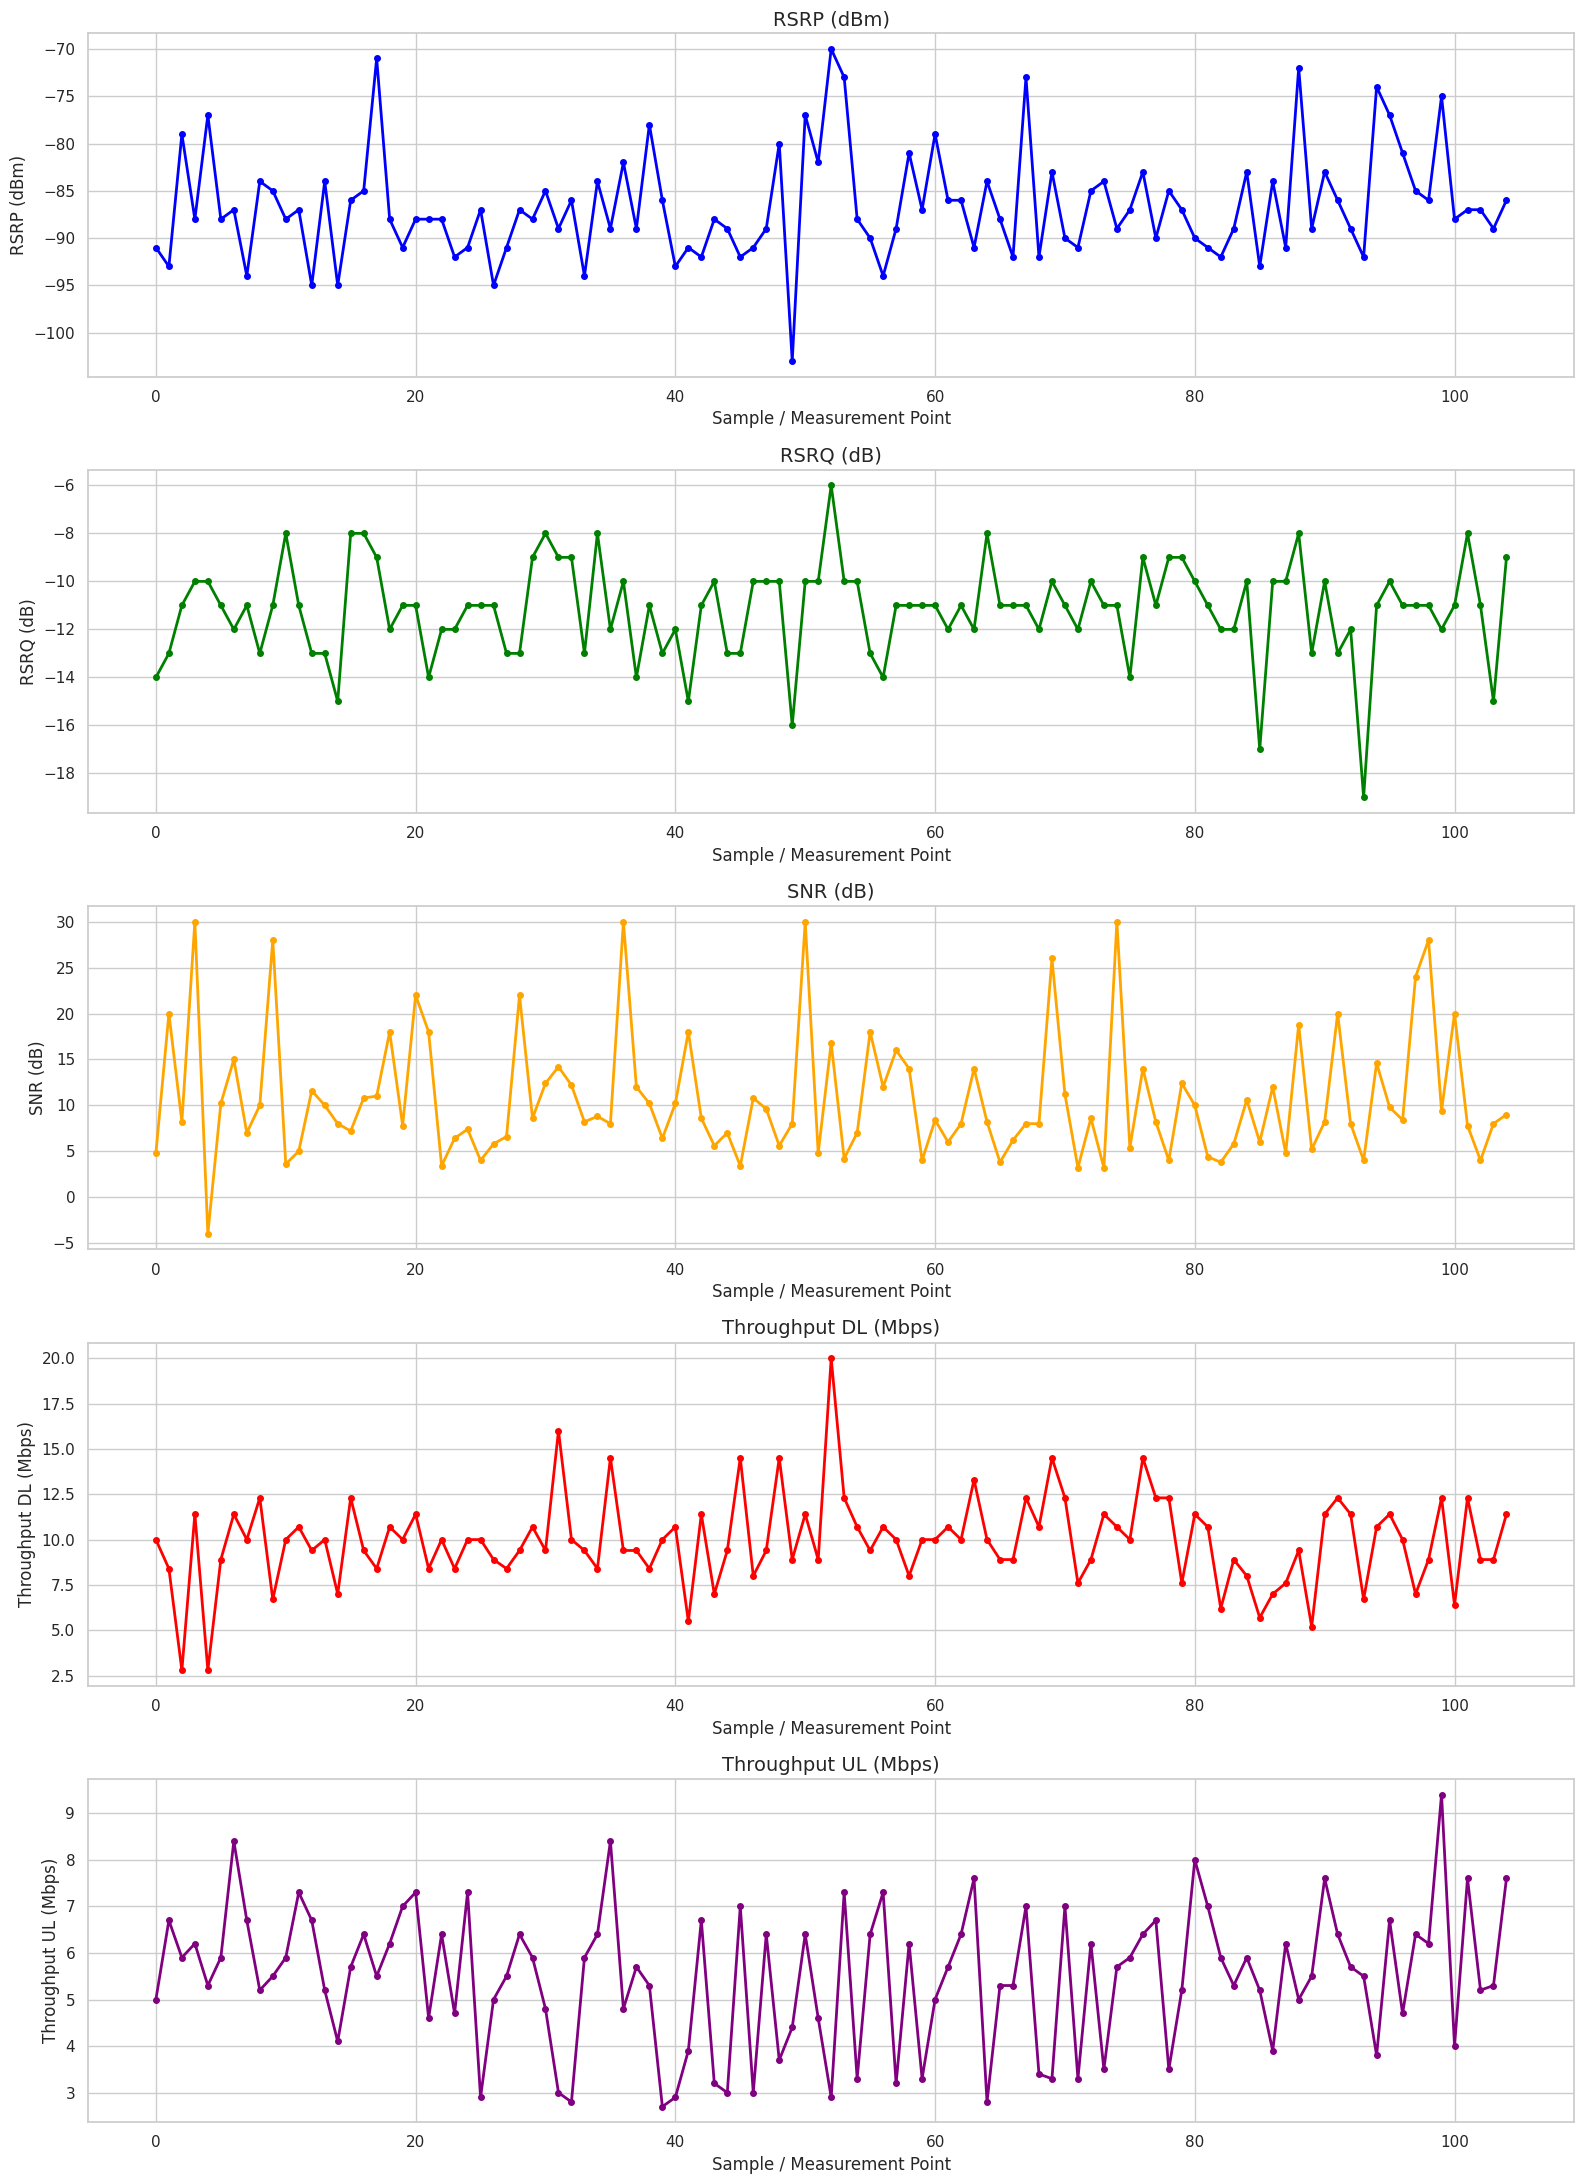

In [18]:
# ============================================
# PLOT GRAFIK
# ============================================
fig, axs = plt.subplots(5, 1, figsize=(16,22))

plot_data = [
    (col_rsrp, 'RSRP (dBm)', 'blue'),
    (col_rsrq, 'RSRQ (dB)', 'green'),
    (col_snr, 'SNR (dB)', 'orange'),
    (col_dl, 'Throughput DL (Mbps)', 'red'),
    (col_ul, 'Throughput UL (Mbps)', 'purple')
]

for i, (col, title, color) in enumerate(plot_data):
    axs[i].plot(df[col], color=color, linewidth=2, marker='o', markersize=4)
    axs[i].set_title(title, fontsize=14)
    axs[i].set_xlabel('Sample / Measurement Point')
    axs[i].set_ylabel(title)
    axs[i].grid(True)

plt.tight_layout()
plt.show()

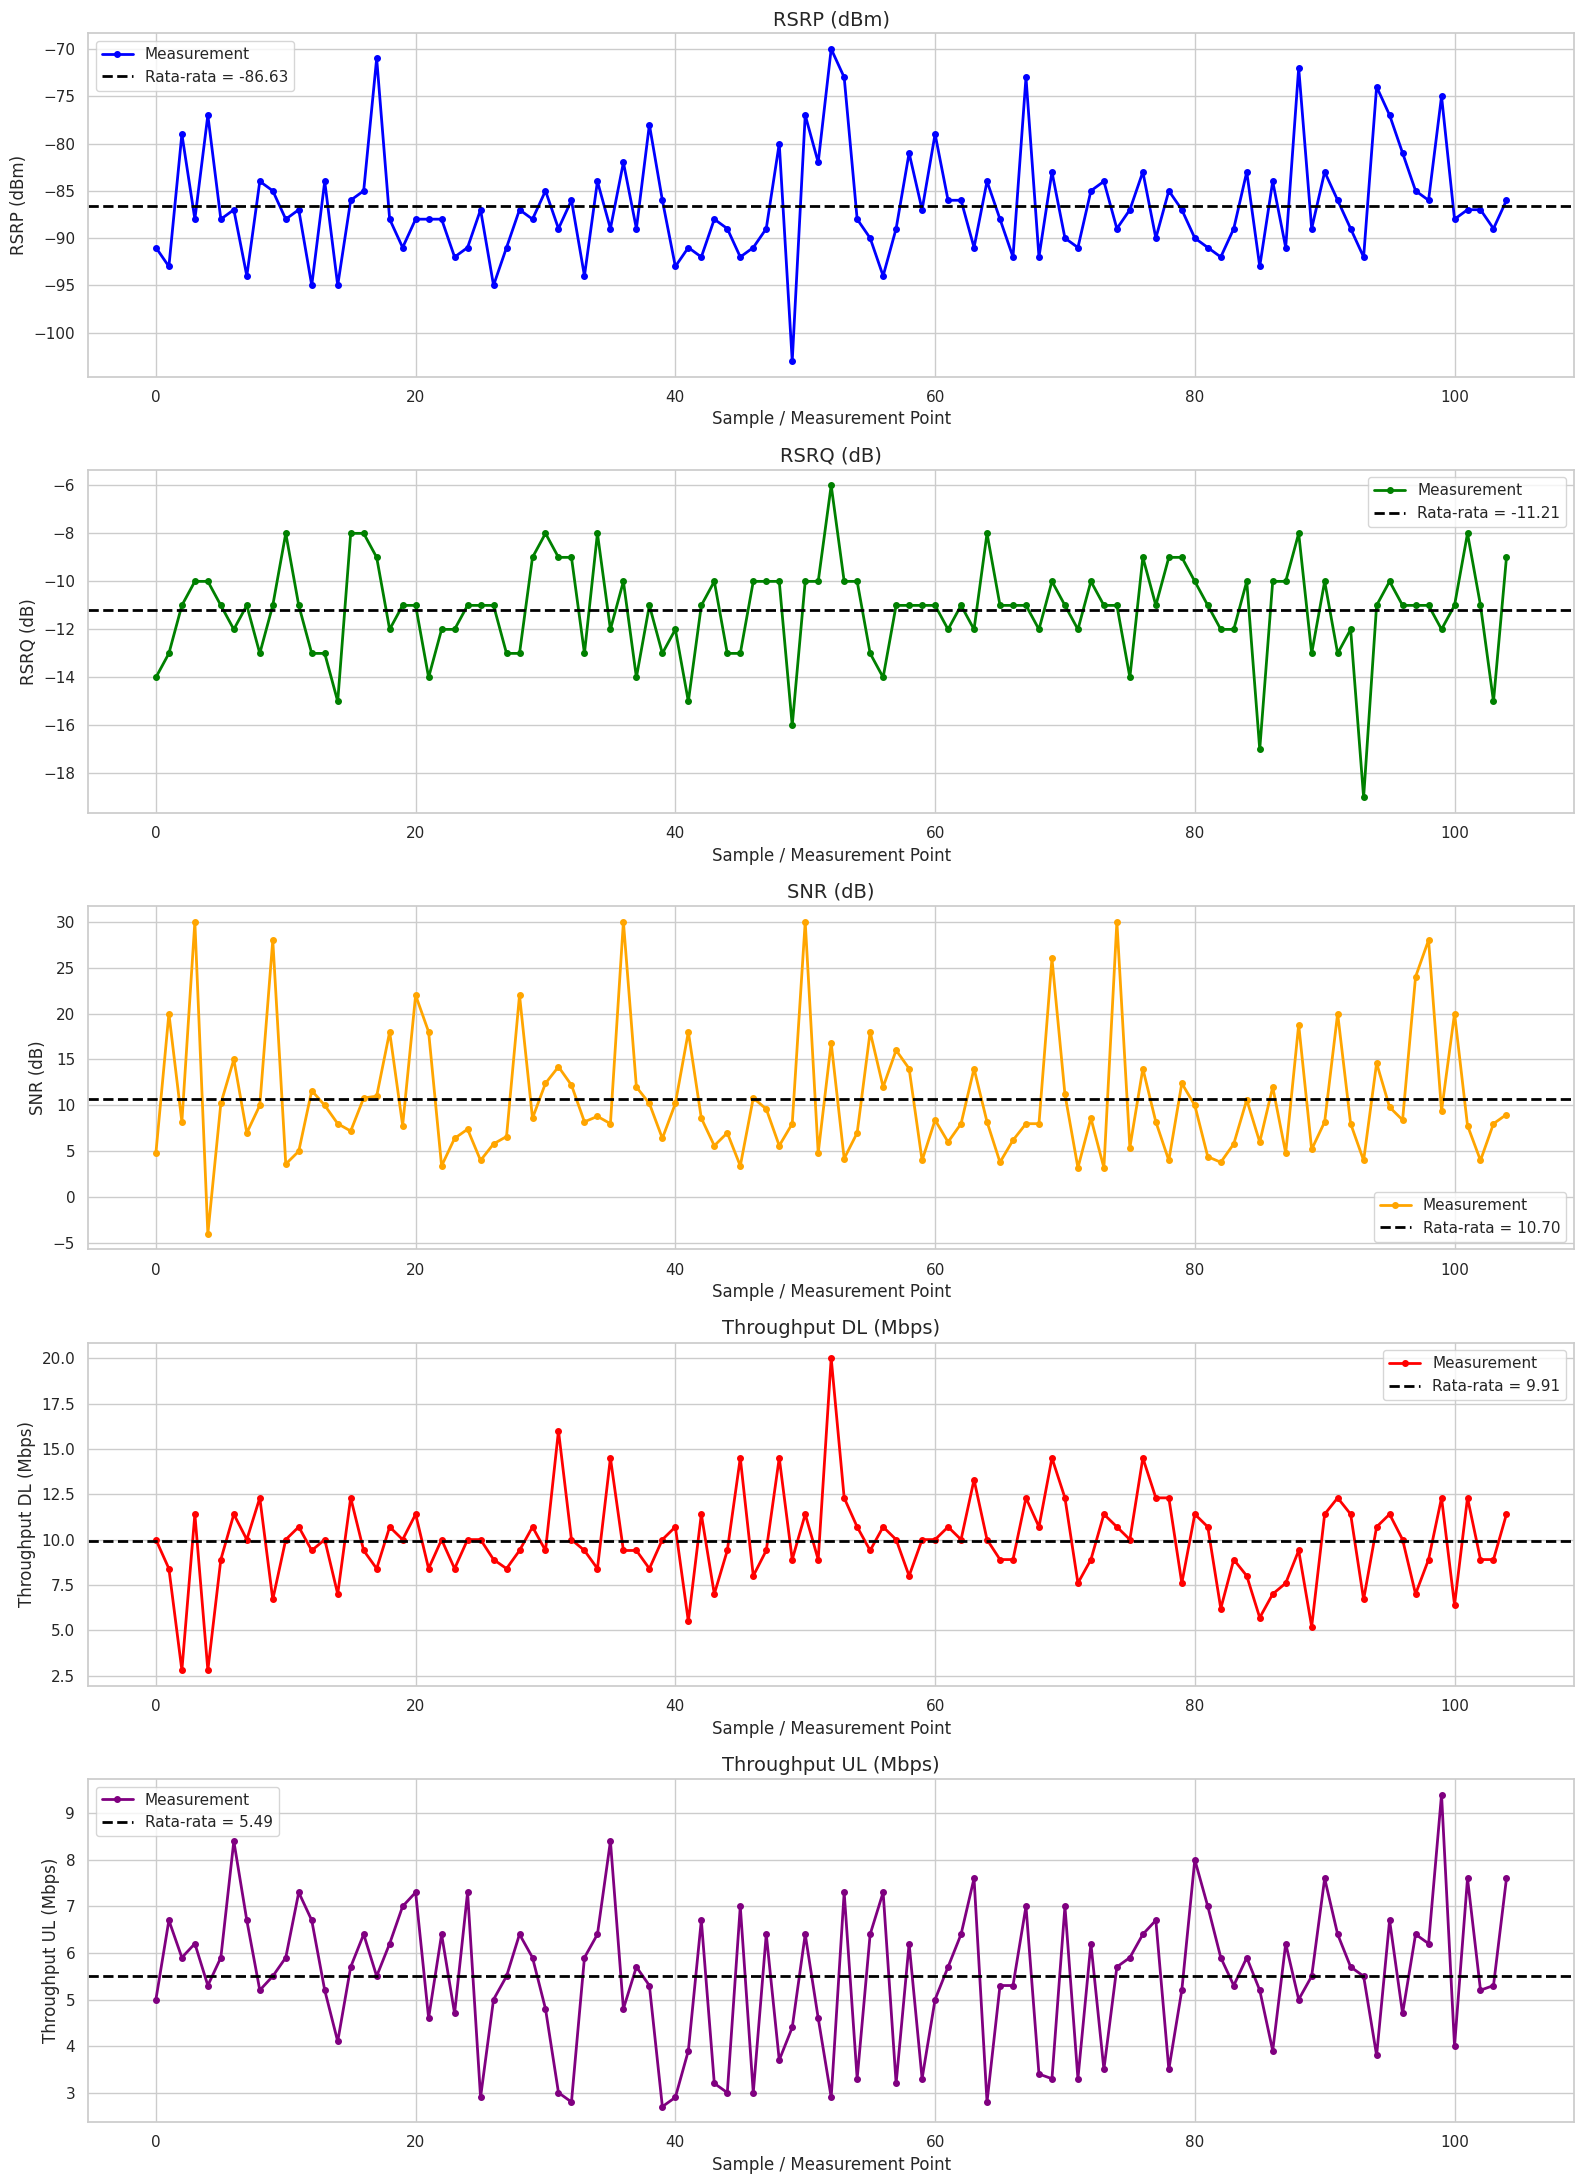

In [19]:
# ============================================
# PLOT GRAFIK + GARIS RATA-RATA
# ============================================
fig, axs = plt.subplots(5, 1, figsize=(16,22))

plot_data = [
    (col_rsrp, 'RSRP (dBm)', 'blue'),
    (col_rsrq, 'RSRQ (dB)', 'green'),
    (col_snr, 'SNR (dB)', 'orange'),
    (col_dl, 'Throughput DL (Mbps)', 'red'),
    (col_ul, 'Throughput UL (Mbps)', 'purple')
]

for i, (col, title, color) in enumerate(plot_data):

    mean_val = df[col].mean()

    # Plot data utama
    axs[i].plot(
        df[col],
        color=color,
        linewidth=2,
        marker='o',
        markersize=4,
        label='Measurement'
    )

    # Plot garis rata-rata
    axs[i].axhline(
        y=mean_val,
        color='black',
        linestyle='--',
        linewidth=2,
        label=f'Rata-rata = {mean_val:.2f}'
    )

    axs[i].set_title(title, fontsize=14)
    axs[i].set_xlabel('Sample / Measurement Point')
    axs[i].set_ylabel(title)
    axs[i].grid(True)
    axs[i].legend()

plt.tight_layout()
plt.show()

In [20]:
print("=== NILAI RATA-RATA PARAMETER ===")
for col in numeric_cols:
    print(f"{col}: {df[col].mean():.2f}")

=== NILAI RATA-RATA PARAMETER ===
RSRP (dBm): -86.63
RSRQ (dB): -11.21
SNR (dB): 10.70
Throughput DL (Mbps): 9.91
Throughput UL (Mbps): 5.49


In [21]:
# ============================================
# ANALISIS KOMBINASI SEL TERBAIK
# ============================================

col_skenario = 'Skenario (Lock)'

summary = df.groupby(col_skenario).agg({
    col_dl: 'mean',
    col_ul: 'mean',
    col_rsrp: 'mean',
    col_rsrq: 'mean',
    col_snr: 'mean'
}).round(2)

summary = summary.sort_values(by=col_dl, ascending=False)

display(summary)

# ============================================
# CARI SKENARIO TERBAIK DL DAN UL
# ============================================
best_dl = summary[col_dl].idxmax()
best_ul = summary[col_ul].idxmax()

print("=== HASIL ANALISIS OPTIMAL ===")
print(f"Skenario terbaik untuk DOWNLOAD  : {best_dl}")
print(f"Rata-rata Throughput DL         : {summary.loc[best_dl, col_dl]:.2f} Mbps")

print()

print(f"Skenario terbaik untuk UPLOAD   : {best_ul}")
print(f"Rata-rata Throughput UL         : {summary.loc[best_ul, col_ul]:.2f} Mbps")

,Throughput DL (Mbps),Throughput UL (Mbps),RSRP (dBm),RSRQ (dB),SNR (dB)
Skenario (Lock),,,,,
EARFCN 500 PCI 214,11.40,5.39,-84.80,-9.93,9.81
EARFCN 500 PCI 261,10.49,6.23,-90.60,-12.53,12.56
EARFCN 1850 PCI 132,10.45,5.99,-86.00,-11.13,13.27
EARFCN 1850 PCI 261,10.05,5.16,-86.13,-11.07,11.31
EARFCN 3500 PCI 214,9.86,5.27,-82.87,-10.60,9.33
EARFCN 500 PCI 132,9.27,5.30,-89.93,-12.00,7.68
EARFCN 3500 PCI 261,7.86,5.13,-86.07,-11.20,10.96


=== HASIL ANALISIS OPTIMAL ===
Skenario terbaik untuk DOWNLOAD  : EARFCN 500 PCI 214
Rata-rata Throughput DL         : 11.40 Mbps

Skenario terbaik untuk UPLOAD   : EARFCN 500 PCI 261
Rata-rata Throughput UL         : 6.23 Mbps


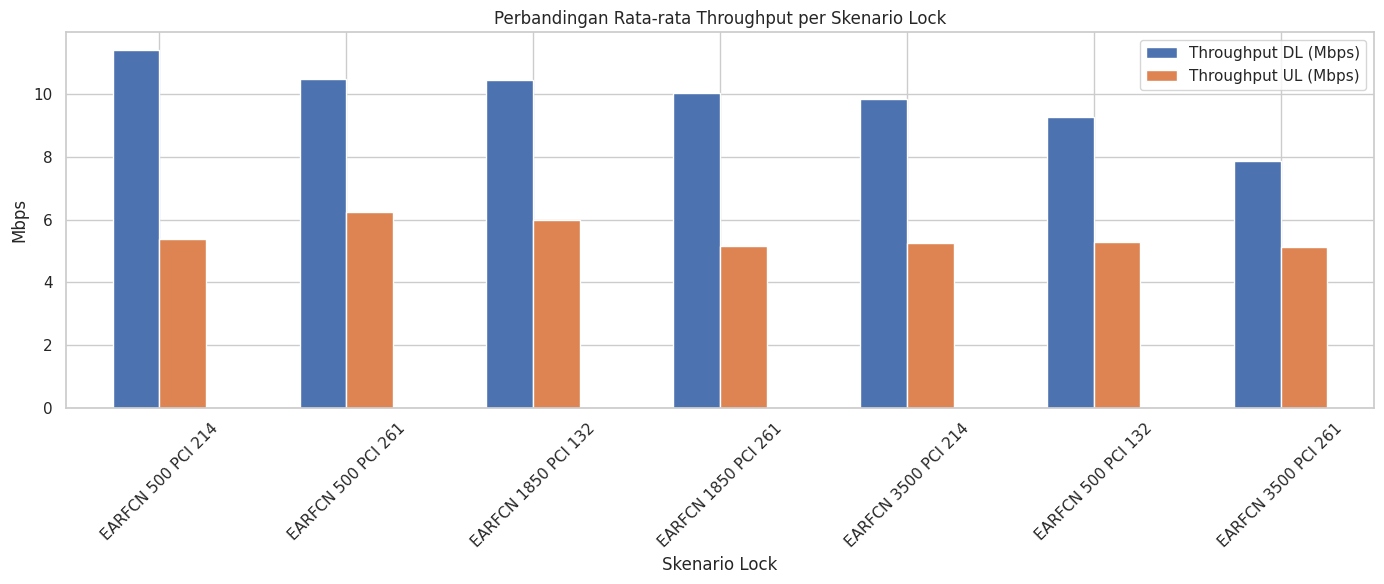

In [22]:
summary[[col_dl, col_ul]].plot(
    kind='bar',
    figsize=(14,6)
)

plt.title('Perbandingan Rata-rata Throughput per Skenario Lock')
plt.ylabel('Mbps')
plt.xlabel('Skenario Lock')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()